*CU Boulder GEOL 3600, fall semester 2025*

# Introduction to numerical modeling, part 1

### Today

- Python packages
- Questions on assignment #4?
- Lake water balance: example of a numerical model

## Lake volume and water level: overview

Tasks:
1. Write a mathematical model that represents the fluctuating water level in a closed-basin lake.
2. Write a Python program to calculate the water level over time, given information about stream inflow, precipitation, and evaporation.

Examples:

- [Great Salt Lake](https://en.wikipedia.org/wiki/Great_Salt_Lake)
- [Mono Lake](https://en.wikipedia.org/wiki/Mono_Lake)
- [Owens Lake](https://en.wikipedia.org/wiki/Owens_Lake)
- [The Dead Sea](https://en.wikipedia.org/wiki/Dead_Sea)
- [Lake Valencia](https://en.wikipedia.org/wiki/Lake_Valencia_(Venezuela))
- [The Miocene Mediterranean Sea](https://en.wikipedia.org/wiki/Messinian_salinity_crisis)

## Conceptualizing the problem using mass balance

Inputs:

- Precipitation
- Stream inflow

Outputs:

- Evaporation

## From concept to math

### Mass balance: in words 

The time rate of change in mass in a system ...

... equals the mass rate in ...

... minus the mass rate out ...

... plus or minus internal sources or sinks.



### Mass balance: as a mathematical equation

In math:

Let $m$ be the mass of water in the lake, $t$ is time, $M_{in}$ rate of mass inflow, $M_{out}$ rate of mass outflow.

$$
\frac{dm}{dt} = M_{in} - M_{out}
$$


Let $\rho$ be density of water, and $V$ the volume of water in the lake. Then:

$m = \rho V$

Inflow from the stream, in volume per time, is $Q$.

Precipitation rate, in depth per time, is $P$.

Evaporation rate (open water), is $E$, depth per time.

Let $A$ be the surface area of the lake.

Mass inflow rate:

$$
M_{in} = \rho Q + \rho P A
$$

$$
M_{out} = \rho E A
$$


$$
\frac{d\rho V}{dt} = \rho Q + \rho P A - \rho E A
$$


$$
\frac{dV}{dt} = Q + PA - EA
$$

$$
V = \frac{1}{3} \pi r^2 h
$$
where $r$ is the lake radius, and $h$ is the depth at middle.

Lake has a spread angle $\alpha$ such that $\tan\alpha = h/r$, or $r = h / \tan\alpha$.

$$
V  = \frac{1}{3} \pi h^3 / (\tan\alpha)^2
$$

$$
h^3 = 3 V (\tan\alpha)^2
$$

$$
h = \left (3 V (\tan\alpha)^2\right)^(1/3)
$$

$$
V = (1 / 3) A h
$$


$$
A = 3 V / h
$$

Now our balance equation is:
$$
\frac{dV}{dt} = Q + 3PV/h - 3EV/h
$$

Factor out:
$$
\frac{dV}{dt} = Q + (3 V / h) (P - E)
$$

$$
\frac{dV}{dt} = Q + (3 V / \left (3 V (\tan\alpha)^2\right)^{1/3} ) (P - E)
$$

$$
\frac{dV}{dt} = Q + (3 V^{2/3} /  ) (P - E)
$$

To see the form of this more clearly, let's rearrange a bit:
$$
\frac{dV}{dt} = Q - \left(\frac{3}{\tan\alpha}\right)^{2/3} (E - P) V^{2/3}
$$

At steady state, the time derivative is zero. In this case, we can solve for the lake volume:
$$
V = \left[ \frac{\tan\alpha}{3}\right] \left[ \frac{Q}{E - P} \right]^{3/2}
$$


#### For reference:

Volume of a cone = $\frac{1}{3} \pi r^2 h$, where $r$ is radius and $h$ the height. 

The angle of the cone is $\tan\alpha = h/r$.

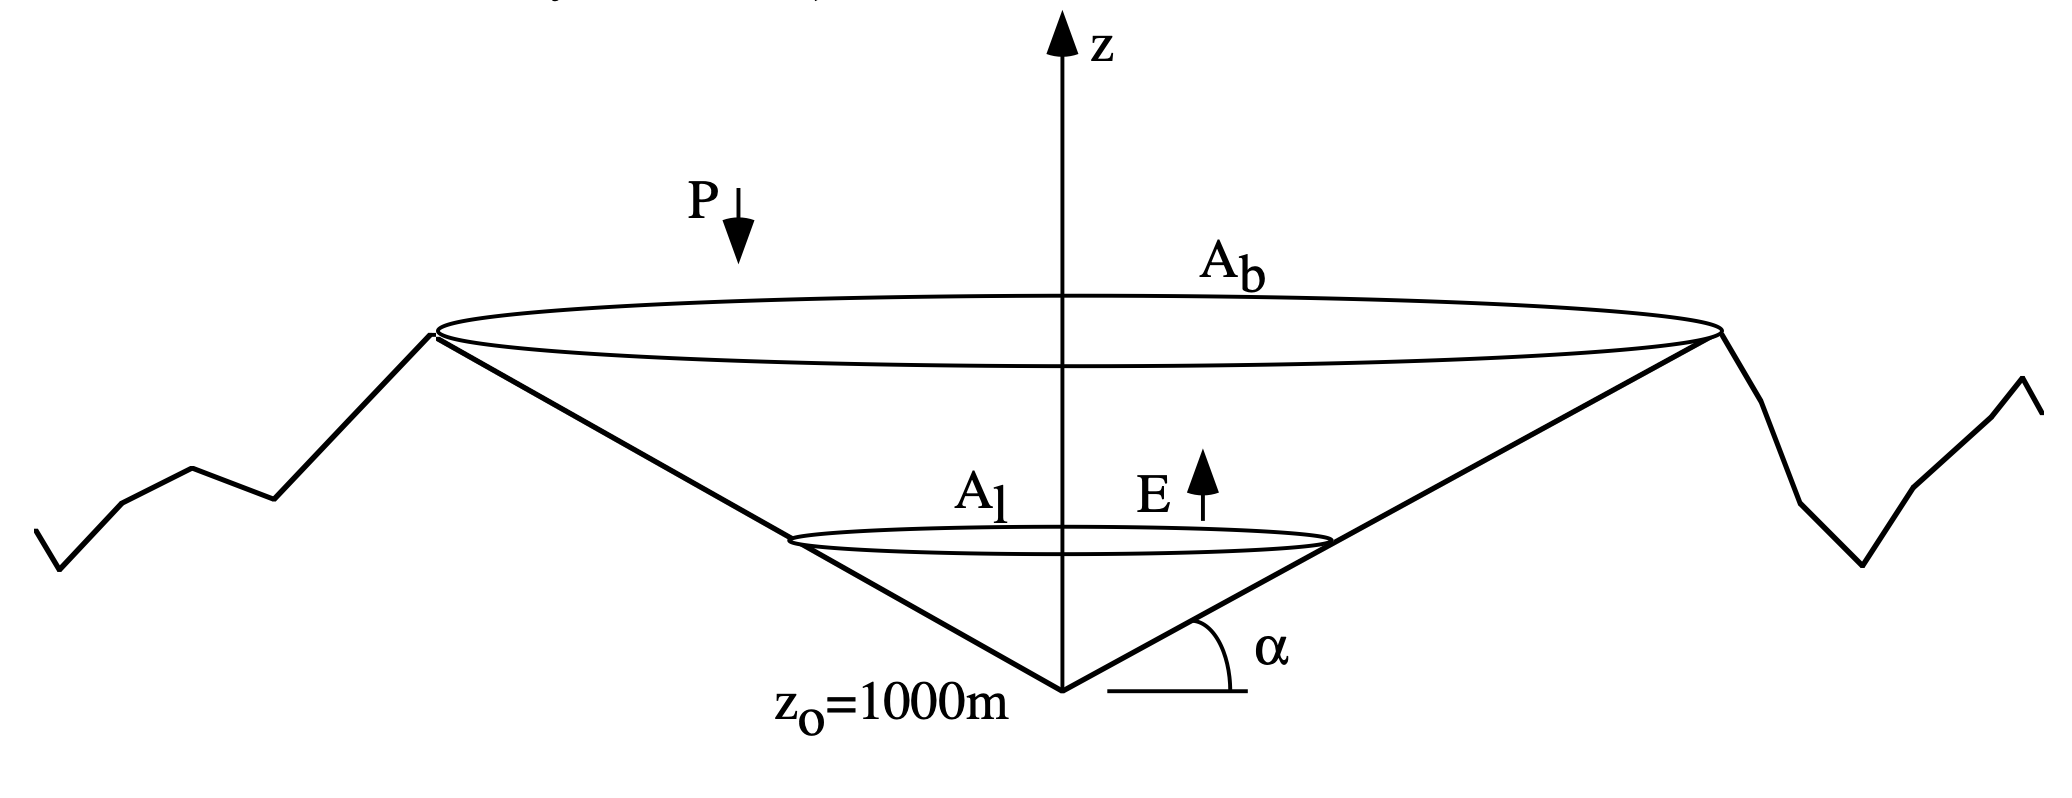

### Deriving a mass balance equation for the closed-lake problem

## Exploring the ODE

We have an ordinary differential equation (ODE). What can it tell us?

### Exploring the steady equilibrium state

#### EXERCISE

Write a program that uses numpy and matplotlib to calculate and plot the steady lake level for:

1. Different values of stream inflow, given fixed evaporation and precipitation rates.
2. Different values of precipitation minus evaporation, given a fixed stream inflow.

## Solving the time-dependent equation

...using the *finite-difference method* with *forward differencing*.

Approximate the derivative with a *finite* difference: let $\Delta t$ be a *time step*, and $\Delta V$ is the change in lake volume during that time interval.

$$
\frac{dV}{dt} \approx \frac{\Delta V}{\Delta t}
$$

$$
\Delta V = V_{k+1} - V_k
$$


$V_k$ represents volume at time step $k$.

Now our difference equation is:

$$
\frac{V_{k+1} - V_k}{\Delta t} = Q + (3 V^{2/3} / \left (3 (\tan\alpha)^2\right)^{1/3} ) (P - E)
$$

$$
V_{k+1} = V_k + \Delta t (Q + (3 V_k^{2/3} / \left (3 (\tan\alpha)^2\right)^{1/3} ) (P - E))
$$


### Quick overview of the finite-difference method

### Writing a finite-difference formulation for the lake equation

### Writing an algorithm in *pseudo-code*

#### High-level structure

```
INITIALIZE
RUN
FINALIZE
```

#### Adding detail

### Initialize

### Run

Here we need a time loop to update the solution for every time step.

### Finalize

Here we clean up and plot the results.

### Wrapping the code inside a function

By placing our code inside a function, we can easily run it repeatedly to explore the effects of different input parameters.

### Advanced topic (if there's extra time): making a class